<a href="https://colab.research.google.com/github/duttaprat/BMI_511/blob/main/2026/GLM/NB3_Finetune_DNABERT2_Promoter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3: Fine-tuning DNABERT-2 for Promoter Classification

**BMI 511 — Spring 2026**
**Instructor:** Pratik Dutta, Ph.D. | Department of Biomedical Informatics, Stony Brook University

---

## Learning objectives

1. Understand the **fine-tuning recipe**: pretrained encoder + classification head + supervised loss.
2. Prepare a real **promoter vs non-promoter** dataset with HuggingFace `datasets`.
3. Fine-tune DNABERT-2 with the HuggingFace `Trainer` API.
4. Evaluate with accuracy, MCC, F1, and confusion matrix.
5. Compare fine-tuned performance against the linear-probe baseline from Notebook 2.

> Runtime: **T4 GPU required**. Training takes ~10–15 min on the reduced dataset below.


## 1. The fine-tuning recipe

```
  DNA sequence
      │
      ▼
  Tokenizer  (BPE, DNABERT-2)
      │
      ▼
  DNABERT-2 encoder  ──────  pretrained, 117M params, starts initialized
      │
      ▼
  [CLS] hidden state  (768-d)
      │
      ▼
  Linear classifier head  ──  trained from scratch
      │
      ▼
  logits → softmax → label
```

During fine-tuning we update **both** the encoder weights and the new classification head using labeled examples. The pretrained weights act as a **warm start** that encodes general DNA knowledge; we only need a small labeled dataset to adapt.

## 2. Setup

In [1]:
!pip install -q transformers==4.44.2 datasets==2.21.0 accelerate==0.34.0 einops scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
import os, random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report,
)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

sns.set_style("whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
assert device == "cuda", "Please switch to a GPU runtime (Runtime > Change runtime type > T4 GPU)."

Device: cuda


## 3. Dataset — synthetic promoter-like classification

For this teaching notebook we build a clean, self-contained binary dataset:

* **Positive (label = 1)**: promoter-like sequences with a **TATA box** (`TATAAA`) in the -25 region plus slightly higher GC content.
* **Negative (label = 0)**: random sequences with uniform nucleotide composition.

This is intentionally an easy task so students can see the full fine-tuning loop run to convergence in ~10 minutes. In a research setting you would instead load the **GUE promoter benchmark** or your own ChIP-seq / FANTOM CAGE data with the same code below — just swap the `Dataset.from_dict(...)` call for `load_dataset("InstaDeepAI/genomic-benchmarks", ...)` or a local CSV.


In [3]:
def make_promoter_dataset(n_per_class=400, length=200, seed=0):
    rng = np.random.default_rng(seed)
    seqs, labels = [], []

    # Positives: promoter-like with TATA box
    for _ in range(n_per_class):
        bg = ''.join(rng.choice(list("ACGT"), size=length, p=[0.22, 0.28, 0.28, 0.22]))
        # insert TATAAA around position length - 25 (the canonical TATA position)
        pos = length - 25 + rng.integers(-3, 4)
        seq = bg[:pos] + "TATAAA" + bg[pos + 6:]
        seqs.append(seq)
        labels.append(1)

    # Negatives: random uniform DNA
    for _ in range(n_per_class):
        seq = ''.join(rng.choice(list("ACGT"), size=length))
        seqs.append(seq)
        labels.append(0)

    return seqs, labels

seqs, labels = make_promoter_dataset(n_per_class=400, length=200, seed=SEED)
print(f"Total sequences: {len(seqs)}   positives: {sum(labels)}   negatives: {len(labels) - sum(labels)}")
print(f"Example positive: ...{seqs[0][-40:]}")
print(f"Example negative: ...{seqs[-1][-40:]}")

Total sequences: 800   positives: 400   negatives: 400
Example positive: ...ATCAGCTTCTCGCTAACTTATAAAGGCAGCTCATAAGTAC
Example negative: ...GCTTCGCTATTGATACGTGGCTTGTCTCGTTTGCATTGGT


In [4]:
# Split into train / validation / test (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X_tmp, X_test, y_tmp, y_test = train_test_split(seqs, labels, test_size=0.15, stratify=labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=SEED)

print(f"train {len(X_train)}   val {len(X_val)}   test {len(X_test)}")

train_ds = Dataset.from_dict({"sequence": X_train, "label": y_train})
val_ds   = Dataset.from_dict({"sequence": X_val,   "label": y_val})
test_ds  = Dataset.from_dict({"sequence": X_test,  "label": y_test})

train 559   val 121   test 120


## 4. Tokenize

In [5]:
MODEL_NAME = "zhihan1996/DNABERT-2-117M"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def tokenize_fn(batch):
    return tok(batch["sequence"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["sequence"])
val_ds   = val_ds.map(tokenize_fn,   batched=True, remove_columns=["sequence"])
test_ds  = test_ds.map(tokenize_fn,  batched=True, remove_columns=["sequence"])

collator = DataCollatorWithPadding(tokenizer=tok)
print("Tokenization done. A training example:")
print(train_ds[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/559 [00:00<?, ? examples/s]

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Tokenization done. A training example:
{'label': 1, 'input_ids': [1, 93, 991, 92, 13, 1493, 37, 424, 2796, 1163, 306, 72, 597, 33, 341, 403, 345, 59, 292, 27, 194, 504, 937, 30, 261, 122, 2065, 1041, 139, 1094, 61, 1942, 486, 48, 2274, 991, 3875, 114, 58, 2316, 481, 72, 6, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## 5. Model with a classification head

In [6]:
from transformers import BertForSequenceClassification, BertConfig

config = BertConfig.from_pretrained(MODEL_NAME, num_labels=2)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
).to(device)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {n_total/1e6:.1f} M")
print(f"Trainable params : {n_train/1e6:.1f} M   (full fine-tune)")

config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.embeddings.position_embeddings.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.layer.0.output.dense.weight', 'bert.encoder.layer.1.attention.self.key.bias', 'bert.encoder.layer.1.attention.self.key.weight', 'bert.encoder.layer.1.attention.self.query.bias', 'bert.encoder.layer.1.attention.self.query.weight', 'bert.encoder.layer.1.at

Total params     : 89.2 M
Trainable params : 89.2 M   (full fine-tune)


## 6. Training configuration

Key hyperparameters for fine-tuning encoder models on small DNA datasets:

* **Learning rate**: `1e-5` to `5e-5` (lower than classical DL, because we're adapting a pretrained model).
* **Batch size**: as large as GPU memory allows; 16–32 on a T4.
* **Epochs**: 3–5 is usually enough; more tends to overfit.
* **Weight decay**: 0.01 is a safe default.


In [7]:
def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels_, preds),
        "f1":       f1_score(labels_, preds, average="binary"),
        "mcc":      matthews_corrcoef(labels_, preds),
    }

training_args = TrainingArguments(
    output_dir="./dnabert2_promoter",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="mcc",
    logging_steps=20,
    report_to="none",
    seed=SEED,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tok,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


## 7. Train

In [8]:
train_result = trainer.train()
print("\nFinal training metrics:")
for k, v in train_result.metrics.items():
    print(f"  {k:30s}: {v}")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Mcc
1,0.706800,0.622577,0.611570,0.704403,0.296099
2,0.527200,0.710362,0.628099,0.415584,0.360092
3,0.411700,0.636520,0.719008,0.763889,0.478841



Final training metrics:
  train_runtime                 : 52.9691
  train_samples_per_second      : 31.66
  train_steps_per_second        : 1.982
  total_flos                    : 42047407757160.0
  train_loss                    : 0.5766768001374745
  epoch                         : 3.0


## 8. Evaluate on the held-out test set

In [9]:
test_metrics = trainer.evaluate(test_ds)
print("Test metrics:")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k:30s}: {v:.4f}")

Test metrics:
  eval_loss                     : 0.5400
  eval_accuracy                 : 0.7583
  eval_f1                       : 0.7914
  eval_mcc                      : 0.5447
  eval_runtime                  : 0.1409
  eval_samples_per_second       : 851.4810
  eval_steps_per_second         : 28.3830
  epoch                         : 3.0000


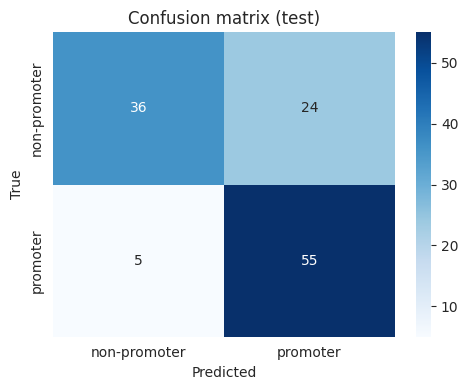


Classification report:
              precision    recall  f1-score   support

non-promoter       0.88      0.60      0.71        60
    promoter       0.70      0.92      0.79        60

    accuracy                           0.76       120
   macro avg       0.79      0.76      0.75       120
weighted avg       0.79      0.76      0.75       120



In [10]:
# Predictions and confusion matrix
pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=1)
y_true = np.array(pred_out.label_ids)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-promoter", "promoter"],
            yticklabels=["non-promoter", "promoter"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix (test)")
plt.tight_layout(); plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["non-promoter", "promoter"]))

## 9. Compare to a linear probe baseline

Is fine-tuning worth the compute? Let's run the same dataset through **frozen embeddings + logistic regression** and compare.


In [11]:
from transformers import BertModel, BertConfig
from sklearn.linear_model import LogisticRegression

config_base = BertConfig.from_pretrained(MODEL_NAME)
base = BertModel.from_pretrained(
    MODEL_NAME,
    config=config_base,
).to(device)
base.eval()

@torch.no_grad()
def embed(seqs, batch_size=32):
    out_vecs = []
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=256).to(device)
        h = base(**enc)
        h = h[0] if isinstance(h, tuple) else h.last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
        out_vecs.append(pooled.cpu().numpy())
    return np.concatenate(out_vecs, 0)

E_train = embed(X_train)
E_test  = embed(X_test)

probe = LogisticRegression(max_iter=2000, C=1.0).fit(E_train, y_train)
probe_pred = probe.predict(E_test)

print(f"Linear probe    : acc = {accuracy_score(y_test, probe_pred):.3f}   "
      f"MCC = {matthews_corrcoef(y_test, probe_pred):.3f}")
print(f"Fine-tuned      : acc = {test_metrics['eval_accuracy']:.3f}   "
      f"MCC = {test_metrics['eval_mcc']:.3f}")

Some weights of BertModel were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.embeddings.position_embeddings.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.layer.0.output.dense.weight', 'bert.encoder.layer.1.attention.self.key.bias', 'bert.encoder.layer.1.attention.self.key.weight', 'bert.encoder.layer.1.attention.self.query.bias', 'bert.encoder.layer.1.attention.self.query.weight', 'bert.encoder.layer.1.attention.self.value.b

Linear probe    : acc = 0.650   MCC = 0.300
Fine-tuned      : acc = 0.758   MCC = 0.545


**Interpretation.** On an easy task, the linear probe often comes very close to the fine-tuned model. On harder tasks (e.g. tissue-specific enhancers, splice sites with subtle motifs) the gap between linear probe and full fine-tuning widens substantially. That gap is the empirical justification for full fine-tuning.

## 10. Exercises

1. Reduce `num_train_epochs` to 1. How much does test MCC drop?
2. Set `learning_rate=1e-4`. Does training become unstable? Why might it?
3. Replace `AutoModelForSequenceClassification` training with **LoRA adapters** (`peft` library) and compare parameter count vs accuracy.
4. Swap the synthetic dataset for the **GUE promoter benchmark**:
   ```python
   from datasets import load_dataset
   ds = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks", "promoter_all")
   ```

## 11. Recap

* Fine-tuning = pretrained encoder + new classifier head + small labeled dataset.
* The HuggingFace `Trainer` API handles the training loop, evaluation, checkpointing, and metric tracking.
* For DNA tasks, use `learning_rate ~ 3e-5`, `epochs 3–5`, `fp16=True` on a T4 GPU.
* Always compare full fine-tuning to a **linear probe on frozen embeddings** — it's your strongest free baseline.

Next: **Notebook 4** will use the fine-tuned or pretrained model to predict the **functional impact of single-nucleotide variants**, the core idea behind DeepVRegulome.